In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def epsilon_greedy(n_arms, true_means, n_steps, epsilon):

  Q = np.zeros(n_arms)
  N = np.zeros(n_arms)

  total_reward = 0

  rewards = []
  actions = []

  for step in range(n_steps):

    # Exploration
    if np.random.rand() < epsilon:
      action = np.random.randint(n_arms)   # Random arm

    # Exploitation
    else:
      best_actions = np.flatnonzero(Q == Q.max())
      action = np.random.choice(best_actions)  # Random among the best

    reward = np.random.normal(true_means[action], 1)

    N[action] += 1
    Q[action] += (reward - Q[action]) / N[action]

    total_reward += reward

    rewards.append(total_reward)
    actions.append(action)

  return total_reward, rewards, actions, Q, N

In [3]:
def ucb(n_arms, true_means, n_steps, c):

  Q = np.zeros(n_arms)
  N = np.zeros(n_arms)

  total_reward = 0

  rewards = []
  actions = []

  # Select each arm once
  for action in range(n_arms):

    reward = np.random.normal(true_means[action], 1)

    N[action] += 1
    Q[action] = reward

    total_reward += reward

    rewards.append(total_reward)
    actions.append(action)

  # Main UCB loop
  for step in range(n_arms, n_steps):

    ucb_values = Q + c * np.sqrt(np.log(step + 1) / N)

    best_actions = np.flatnonzero(ucb_values == ucb_values.max())
    action = np.random.choice(best_actions)

    reward = np.random.normal(true_means[action], 1)

    N[action] += 1
    Q[action] += (reward - Q[action]) / N[action]

    total_reward += reward

    rewards.append(total_reward)
    actions.append(action)

  return total_reward, rewards, actions, Q, N

In [4]:
def thompson_sampling(n_arms, true_probs, n_steps):

  rng = np.random.default_rng()
  alpha = np.ones(n_arms, dtype=int)
  beta = np.ones(n_arms, dtype=int)

  total_reward = 0
  rewards = np.empty(n_steps, dtype=int)
  actions = np.empty(n_steps, dtype=int)

  for step in range(n_steps):

    # Sample from posterior distributions
    samples = rng.beta(alpha, beta)
    action = np.argmax(samples)

    # Simulate repayment
    reward = rng.binomial(1, true_probs[action])

    # Update posterior counts
    alpha[action] += reward
    beta[action] += 1 - reward

    total_reward += reward
    rewards[step] = total_reward
    actions[step] = action

  return total_reward, rewards, actions, alpha, beta

<>:76: SyntaxWarning: invalid escape sequence '\e'
<>:87: SyntaxWarning: invalid escape sequence '\e'
<>:101: SyntaxWarning: invalid escape sequence '\e'
<>:76: SyntaxWarning: invalid escape sequence '\e'
<>:87: SyntaxWarning: invalid escape sequence '\e'
<>:101: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_28765/3766251857.py:76: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(steps, rew_eg, label=f"$\epsilon$-Greedy (Total: {tot_eg:.0f})", color="tab:orange", alpha=0.8)
/tmp/ipykernel_28765/3766251857.py:87: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(steps, rew_eg / steps, label="$\epsilon$-Greedy", color="tab:orange", alpha=0.8)
/tmp/ipykernel_28765/3766251857.py:101: SyntaxWarning: invalid escape sequence '\e'
  plt.bar(x - width, counts_eg, width, label="$\epsilon$-Greedy", color="tab:orange")


                    EXPERIMENTAL METRICS REPORT                       
1. TOTAL REWARDS EARNED (Higher is better):
   - Epsilon-Greedy:  1753 successful repayments
   - UCB:             1767 successful repayments
   - Thompson Sampling: 1805 successful repayments

2. EXPLORATION EFFICIENCY (Capital wasted on high-risk defaults - Lower is better):
   - Epsilon-Greedy:  176 loans issued to sub-optimal tiers
   - UCB:             71 loans issued to sub-optimal tiers
   - Thompson Sampling: 36 loans issued to sub-optimal tiers

3. EXPLOITATION EFFECTIVENESS (% allocation to prime borrowers - Higher is better):
   - Epsilon-Greedy:  91.2%
   - UCB:             96.5%
   - Thompson Sampling: 98.2%

4. CONVERGENCE SPEED (Steps required to steady-state target 90%+ prime borrowers):
   - Epsilon-Greedy:  144 steps
   - UCB:             180 steps
   - Thompson Sampling: 105 steps

5. IDENTIFICATION PROFILE (Total selections per credit tier [Tier 0, Tier 1, Tier 2, Tier 3]):
   - Epsilon-Greedy:  

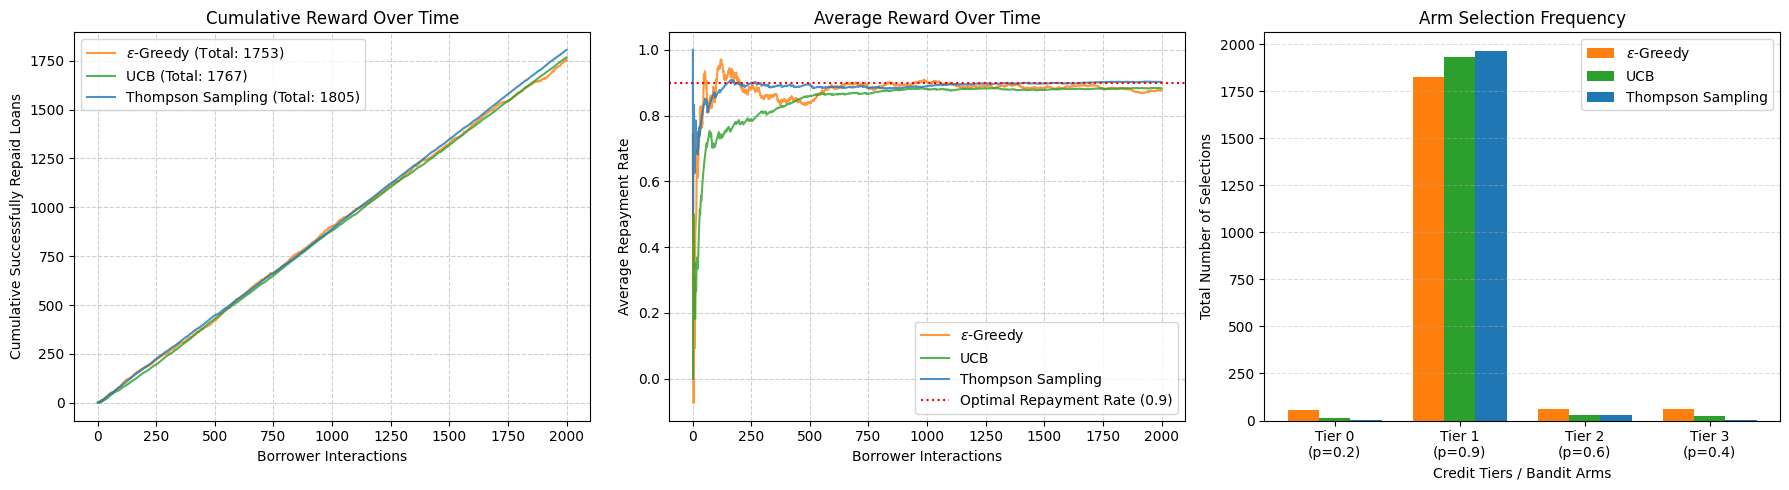

In [10]:
# ==============================================================================
# Simulation Setup
# ==============================================================================
np.random.seed(42)  # For reproducibility
n_steps = 2000
# 4 credit tiers with different true repayment probabilities
# Arm 1 (Index 1) is the most creditworthy group (90% repayment rate)
true_probs = np.array([0.2, 0.9, 0.6, 0.4])
n_arms = len(true_probs)

# Run simulations
tot_eg, rew_eg, act_eg, Q_eg, N_eg = epsilon_greedy(n_arms, true_probs, n_steps, epsilon=0.1)
tot_ucb, rew_ucb, act_ucb, Q_ucb, N_ucb = ucb(n_arms, true_probs, n_steps, c=1.0)
tot_ts, rew_ts, act_ts, alpha_ts, beta_ts = thompson_sampling(n_arms, true_probs, n_steps)

# Compute counts for arm-selection frequency
counts_eg = np.bincount(act_eg, minlength=n_arms)
counts_ucb = np.bincount(act_ucb, minlength=n_arms)
counts_ts = np.bincount(act_ts, minlength=n_arms)

optimal_arm = np.argmax(true_probs)
print("======================================================================")
print("                    EXPERIMENTAL METRICS REPORT                       ")
print("======================================================================")

# Q1: Total Reward Earned
print(f"1. TOTAL REWARDS EARNED (Higher is better):")
print(f"   - Epsilon-Greedy:  {rew_eg[-1]:.0f} successful repayments")
print(f"   - UCB:             {rew_ucb[-1]:.0f} successful repayments")
print(f"   - Thompson Sampling: {rew_ts[-1]:.0f} successful repayments\n")

# Q2: Exploration Efficiency (How many times did they pull sub-optimal, high-risk arms?)
bad_eg = np.sum(act_eg != optimal_arm)
bad_ucb = np.sum(act_ucb != optimal_arm)
bad_ts = np.sum(act_ts != optimal_arm)
print(f"2. EXPLORATION EFFICIENCY (Capital wasted on high-risk defaults - Lower is better):")
print(f"   - Epsilon-Greedy:  {bad_eg} loans issued to sub-optimal tiers")
print(f"   - UCB:             {bad_ucb} loans issued to sub-optimal tiers")
print(f"   - Thompson Sampling: {bad_ts} loans issued to sub-optimal tiers\n")

# Q3: Exploitation Effectiveness (Percentage allocation to prime borrowers)
print(f"3. EXPLOITATION EFFECTIVENESS (% allocation to prime borrowers - Higher is better):")
print(f"   - Epsilon-Greedy:  {(100 * (n_steps - bad_eg) / n_steps):.1f}%")
print(f"   - UCB:             {(100 * (n_steps - bad_ucb) / n_steps):.1f}%")
print(f"   - Thompson Sampling: {(100 * (n_steps - bad_ts) / n_steps):.1f}%\n")

# Q4: Convergence Speed (Step index when the algorithm locks onto the optimal arm 90%+ of the time)
def find_convergence(actions, optimal_arm, window=100):
    for t in range(window, len(actions)):
        if np.mean(actions[t-window:t] == optimal_arm) >= 0.90:
            return t
    return None

print(f"4. CONVERGENCE SPEED (Steps required to steady-state target 90%+ prime borrowers):")
print(f"   - Epsilon-Greedy:  {find_convergence(act_eg, optimal_arm)} steps")
print(f"   - UCB:             {find_convergence(act_ucb, optimal_arm)} steps")
print(f"   - Thompson Sampling: {find_convergence(act_ts, optimal_arm)} steps\n")

# Q5: Identification Accuracy
print(f"5. IDENTIFICATION PROFILE (Total selections per credit tier [Tier 0, Tier 1, Tier 2, Tier 3]):")
print(f"   - Epsilon-Greedy:   {np.bincount(act_eg, minlength=n_arms)}")
print(f"   - UCB:              {np.bincount(act_ucb, minlength=n_arms)}")
print(f"   - Thompson Sampling: {np.bincount(act_ts, minlength=n_arms)}")
print("======================================================================\n")


# ==============================================================================
# Visualizations
# ==============================================================================
steps = np.arange(1, n_steps + 1)

plt.figure(figsize=(18, 5))

# Plot 1: Cumulative Reward over time
plt.subplot(1, 3, 1)
plt.plot(steps, rew_eg, label=f"$\epsilon$-Greedy (Total: {tot_eg:.0f})", color="tab:orange", alpha=0.8)
plt.plot(steps, rew_ucb, label=f"UCB (Total: {tot_ucb:.0f})", color="tab:green", alpha=0.8)
plt.plot(steps, rew_ts, label=f"Thompson Sampling (Total: {tot_ts})", color="tab:blue", alpha=0.8)
plt.title("Cumulative Reward Over Time")
plt.xlabel("Borrower Interactions")
plt.ylabel("Cumulative Successfully Repaid Loans")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# Plot 2: Average Reward over time (Probability of Repayment)
plt.subplot(1, 3, 2)
plt.plot(steps, rew_eg / steps, label="$\epsilon$-Greedy", color="tab:orange", alpha=0.8)
plt.plot(steps, rew_ucb / steps, label="UCB", color="tab:green", alpha=0.8)
plt.plot(steps, rew_ts / steps, label="Thompson Sampling", color="tab:blue", alpha=0.8)
plt.axhline(y=max(true_probs), color="r", linestyle=":", label="Optimal Repayment Rate (0.9)")
plt.title("Average Reward Over Time")
plt.xlabel("Borrower Interactions")
plt.ylabel("Average Repayment Rate")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# Plot 3: Arm-Selection Frequency
plt.subplot(1, 3, 3)
x = np.arange(n_arms)
width = 0.25
plt.bar(x - width, counts_eg, width, label="$\epsilon$-Greedy", color="tab:orange")
plt.bar(x, counts_ucb, width, label="UCB", color="tab:green")
plt.bar(x + width, counts_ts, width, label="Thompson Sampling", color="tab:blue")
plt.title("Arm Selection Frequency")
plt.xlabel("Credit Tiers / Bandit Arms")
plt.ylabel("Total Number of Selections")
plt.xticks(x, [f"Tier {i}\n(p={true_probs[i]})" for i in range(n_arms)])
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
plt.show()